In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

MAP_X = 60
SPEC_POINTS = 1024

def load_spectra(y_file, x_file, row_start, row_end, col_start, col_end):
    x_axis = np.loadtxt(x_file)
    spectra = []
    with open(y_file, 'r') as f:
        for row in range(row_end):
            for col in range(MAP_X):
                spectrum = []
                for k in range(SPEC_POINTS):
                    line = f.readline()
                    if not line:
                        break
                    spectrum.append(float(line.strip()))
                if len(spectrum) == SPEC_POINTS:
                    if row >= row_start and col_start <= col < col_end:
                        spectra.append(spectrum)
    return x_axis, np.array(spectra)

# WSe2 CVD 로딩
print('WSe2 CVD 읽는 중...')
x_cvd, spectra_cvd = load_spectra(
    '1 Export File (Y-Axis).txt',
    '1 Export File (X-Axis).txt',
    row_start=15, row_end=45,
    col_start=15, col_end=45
)
print(f'CVD shape: {spectra_cvd.shape}')

# WSe2 기계적 박리 로딩
print('WSe2 기계적 박리 읽는 중...')
x_exf, spectra_exf = load_spectra(
    '2 Export File (Y-Axis).txt',
    '2 Export File (X-Axis).txt',
    row_start=5, row_end=35,
    col_start=15, col_end=45
)
print(f'Exfoliated shape: {spectra_exf.shape}')
print('완료!')

WSe2 CVD 읽는 중...
CVD shape: (900, 1024)
WSe2 기계적 박리 읽는 중...
Exfoliated shape: (900, 1024)
완료!


In [3]:
def remove_cosmic_ray(s, threshold=5):
    med = np.median(s)
    std = np.std(s)
    mask = s > med + threshold * std
    sc = s.copy()
    for i in np.where(mask)[0]:
        if 0 < i < len(sc)-1:
            sc[i] = (sc[i-1] + sc[i+1]) / 2
    return sc

def process_spectra(spectra):
    baseline = np.percentile(spectra, 10, axis=1, keepdims=True)
    spectra_sub = spectra - baseline
    spectra_2d = spectra_sub.reshape(30, 30, 1024)
    row_means = spectra_2d.mean(axis=(1, 2), keepdims=True)
    global_mean = spectra_2d.mean()
    spectra_norm = spectra_2d * (global_mean / (row_means + 1e-10))
    return spectra_norm.reshape(900, 1024)

def extract_peaks(spectra_norm, x_axis):
    peak_positions = np.zeros((30, 30))
    peak_intensities = np.zeros((30, 30))
    fwhm_map = np.zeros((30, 30))
    for idx in range(900):
        row = idx // 30
        col = idx % 30
        spec = spectra_norm[idx]
        spec_clean = remove_cosmic_ray(spec)
        spec_smooth = savgol_filter(spec_clean, 15, 3)
        peaks, _ = find_peaks(spec_smooth,
                              height=spec_smooth.max()*0.3,
                              prominence=5)
        if len(peaks) > 0:
            main_peak = peaks[np.argmax(spec_smooth[peaks])]
            peak_positions[row, col] = x_axis[main_peak]
            peak_intensities[row, col] = spec_smooth[main_peak]
            half_max = spec_smooth[main_peak] / 2
            left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
            right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
            fwhm_map[row, col] = abs(x_axis[main_peak+right_idx] - x_axis[left_idx])
    return peak_positions, peak_intensities, fwhm_map

# CVD 처리
print('WSe2 CVD 처리 중...')
norm_cvd = process_spectra(spectra_cvd)
pos_cvd, int_cvd, fwhm_cvd = extract_peaks(norm_cvd, x_cvd)
print(f'CVD Peak position: {pos_cvd[pos_cvd>0].min():.1f} ~ {pos_cvd.max():.1f} meV')

# 기계적 박리 처리
print('WSe2 기계적 박리 처리 중...')
norm_exf = process_spectra(spectra_exf)
pos_exf, int_exf, fwhm_exf = extract_peaks(norm_exf, x_exf)
print(f'Exf Peak position: {pos_exf[pos_exf>0].min():.1f} ~ {pos_exf.max():.1f} meV')
print('완료!')

WSe2 CVD 처리 중...
CVD Peak position: 682.3 ~ 931.0 meV
WSe2 기계적 박리 처리 중...
Exf Peak position: 531.8 ~ 784.4 meV
완료!


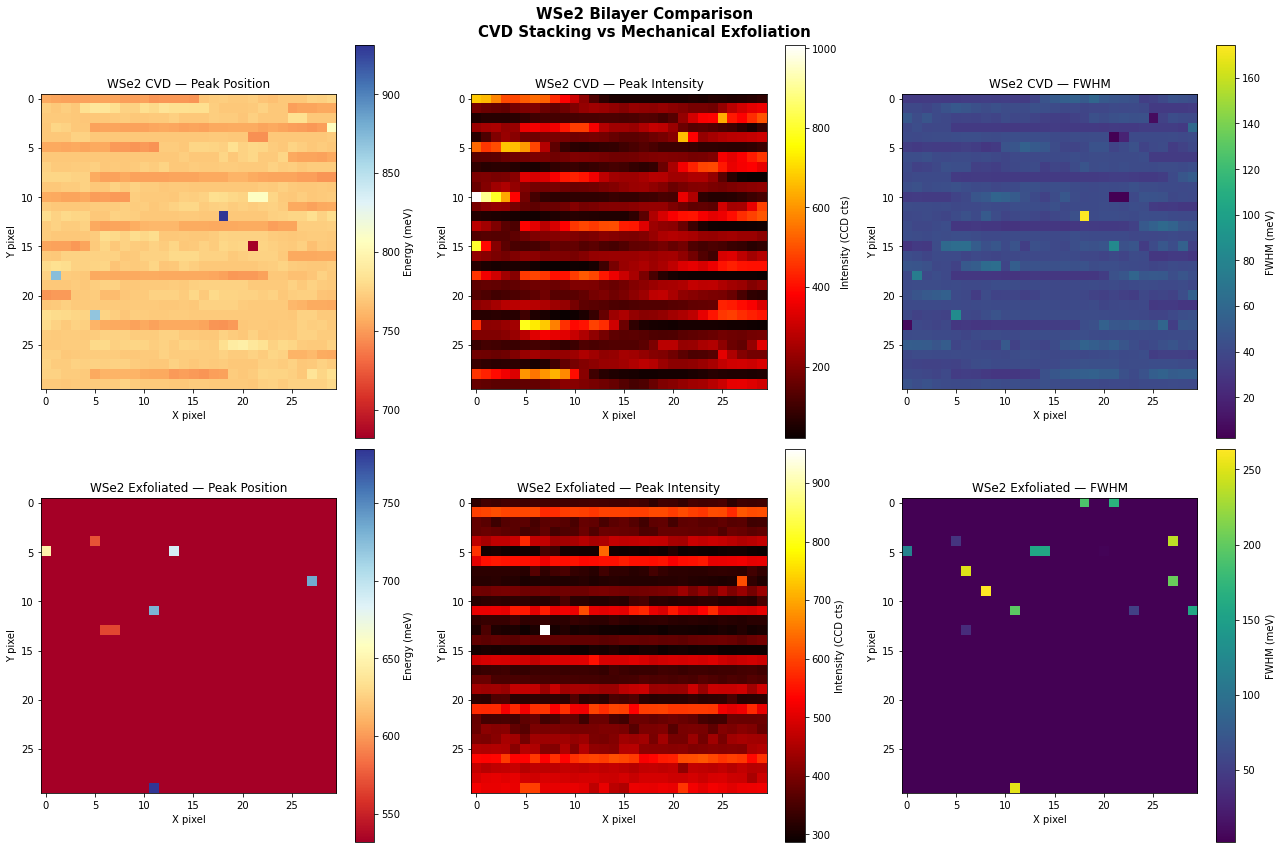

완료!


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# WSe2 CVD — 3개 맵
im1 = axes[0,0].imshow(pos_cvd, cmap='RdYlBu', origin='upper')
axes[0,0].set_title('WSe2 CVD — Peak Position', fontsize=12)
axes[0,0].set_xlabel('X pixel')
axes[0,0].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[0,0], label='Energy (meV)')

im2 = axes[0,1].imshow(int_cvd, cmap='hot', origin='upper')
axes[0,1].set_title('WSe2 CVD — Peak Intensity', fontsize=12)
axes[0,1].set_xlabel('X pixel')
axes[0,1].set_ylabel('Y pixel')
plt.colorbar(im2, ax=axes[0,1], label='Intensity (CCD cts)')

im3 = axes[0,2].imshow(fwhm_cvd, cmap='viridis', origin='upper')
axes[0,2].set_title('WSe2 CVD — FWHM', fontsize=12)
axes[0,2].set_xlabel('X pixel')
axes[0,2].set_ylabel('Y pixel')
plt.colorbar(im3, ax=axes[0,2], label='FWHM (meV)')

# WSe2 기계적 박리 — 3개 맵
im4 = axes[1,0].imshow(pos_exf, cmap='RdYlBu', origin='upper')
axes[1,0].set_title('WSe2 Exfoliated — Peak Position', fontsize=12)
axes[1,0].set_xlabel('X pixel')
axes[1,0].set_ylabel('Y pixel')
plt.colorbar(im4, ax=axes[1,0], label='Energy (meV)')

im5 = axes[1,1].imshow(int_exf, cmap='hot', origin='upper')
axes[1,1].set_title('WSe2 Exfoliated — Peak Intensity', fontsize=12)
axes[1,1].set_xlabel('X pixel')
axes[1,1].set_ylabel('Y pixel')
plt.colorbar(im5, ax=axes[1,1], label='Intensity (CCD cts)')

im6 = axes[1,2].imshow(fwhm_exf, cmap='viridis', origin='upper')
axes[1,2].set_title('WSe2 Exfoliated — FWHM', fontsize=12)
axes[1,2].set_xlabel('X pixel')
axes[1,2].set_ylabel('Y pixel')
plt.colorbar(im6, ax=axes[1,2], label='FWHM (meV)')

plt.suptitle('WSe2 Bilayer Comparison\nCVD Stacking vs Mechanical Exfoliation',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('WSe2_comparison.png', dpi=150)
plt.show()
print('완료!')

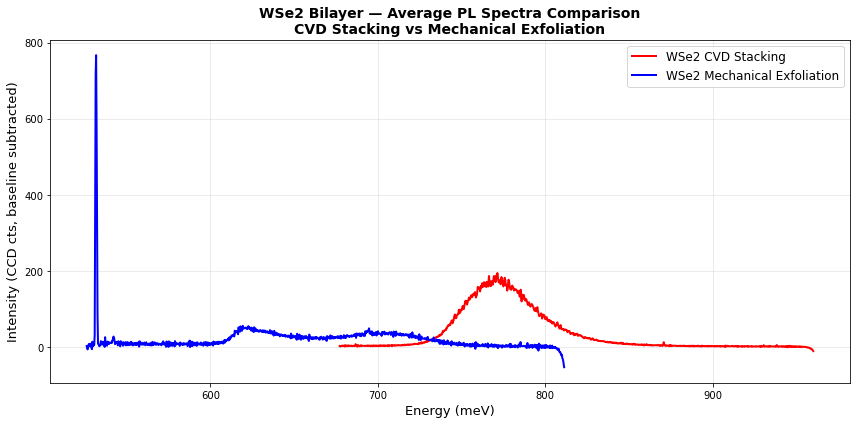

완료!


In [7]:
# 평균 스펙트럼 비교
baseline_cvd = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)

mean_cvd = (spectra_cvd - baseline_cvd).mean(axis=0)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)

# Cosmic ray 제거
mean_cvd_clean = remove_cosmic_ray(mean_cvd)
mean_exf_clean = remove_cosmic_ray(mean_exf)

plt.figure(figsize=(12, 6))
plt.plot(x_cvd, mean_cvd_clean, color='red', linewidth=2,
         label='WSe2 CVD Stacking')
plt.plot(x_exf, mean_exf_clean, color='blue', linewidth=2,
         label='WSe2 Mechanical Exfoliation')

plt.xlabel('Energy (meV)', fontsize=13)
plt.ylabel('Intensity (CCD cts, baseline subtracted)', fontsize=13)
plt.title('WSe2 Bilayer — Average PL Spectra Comparison\nCVD Stacking vs Mechanical Exfoliation',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('WSe2_spectra_comparison.png', dpi=150)
plt.show()
print('완료!')

In [9]:
# 두 헤더 파일 내용 확인
print('=== CVD 헤더 ===')
with open('1 Export File (Header).txt', 'r') as f:
    print(f.read())

print('\n=== 기계적 박리 헤더 ===')
with open('2 Export File (Header).txt', 'r') as f:
    print(f.read())

=== CVD 헤더 ===
//Exported ASCII-File
[Header]
FileName = C:\Users\kyb88\OneDrive - 성균관대학교\바탕 화면\WITec_Files\230414 Wse2bi NSOM.WIP
GraphName = Scan_000_Spec.Data 1_F (Sub BG)
SizeX = 100
SizeY = 100
SizeGraph = 1024
DataUnit = CCD cts


=== 기계적 박리 헤더 ===
//Exported ASCII-File
[Header]
FileName = C:\Users\kyb88\OneDrive - 성균관대학교\바탕 화면\WITec_Files\230420 ws2 bilayer nsom.WIP
GraphName = Scan_000_Spec.Data 1_F
SizeX = 100
SizeY = 100
SizeGraph = 1024
DataUnit = CCD cts



In [11]:
# nm → meV 변환
def nm_to_meV(wavelength_nm):
    return (1239.8 / wavelength_nm) * 1000

# 변환
x_cvd_meV = nm_to_meV(x_cvd)
x_exf_meV = nm_to_meV(x_exf)

print(f'CVD X축 변환:')
print(f'  nm:  {x_cvd.min():.1f} ~ {x_cvd.max():.1f} nm')
print(f'  meV: {x_cvd_meV.min():.1f} ~ {x_cvd_meV.max():.1f} meV')

print(f'\n기계적 박리 X축 변환:')
print(f'  nm:  {x_exf.min():.1f} ~ {x_exf.max():.1f} nm')
print(f'  meV: {x_exf_meV.min():.1f} ~ {x_exf_meV.max():.1f} meV')

CVD X축 변환:
  nm:  677.2 ~ 960.0 nm
  meV: 1291.4 ~ 1830.8 meV

기계적 박리 X축 변환:
  nm:  526.2 ~ 811.3 nm
  meV: 1528.2 ~ 2356.3 meV


공통 범위: 1528 ~ 1831 meV


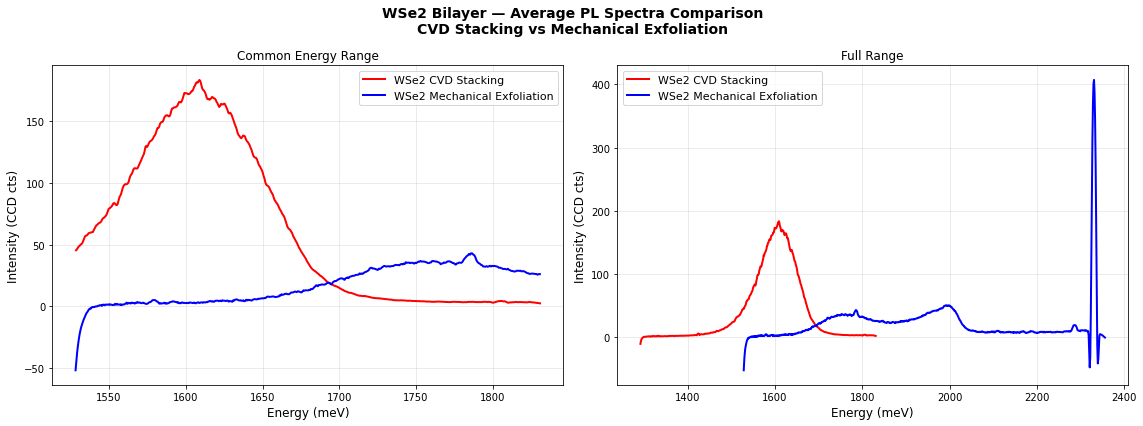

완료!


In [13]:
# nm → meV 변환
def nm_to_meV(nm):
    return (1239.8 / nm) * 1000

x_cvd_meV = nm_to_meV(x_cvd)
x_exf_meV = nm_to_meV(x_exf)

# meV로 변환 후 오름차순 정렬 (nm은 내림차순이라 뒤집어야 함)
sort_cvd = np.argsort(x_cvd_meV)
sort_exf = np.argsort(x_exf_meV)

x_cvd_sorted = x_cvd_meV[sort_cvd]
x_exf_sorted = x_exf_meV[sort_exf]

# 베이스라인 제거 + 평균
baseline_cvd = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_cvd = (spectra_cvd - baseline_cvd).mean(axis=0)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)

# Cosmic ray 제거 + smoothing
mean_cvd_clean = savgol_filter(remove_cosmic_ray(mean_cvd[sort_cvd]), 15, 3)
mean_exf_clean = savgol_filter(remove_cosmic_ray(mean_exf[sort_exf]), 15, 3)

# 공통 범위
e_min = max(x_cvd_sorted.min(), x_exf_sorted.min())
e_max = min(x_cvd_sorted.max(), x_exf_sorted.max())
print(f'공통 범위: {e_min:.0f} ~ {e_max:.0f} meV')

mask_cvd = (x_cvd_sorted >= e_min) & (x_cvd_sorted <= e_max)
mask_exf = (x_exf_sorted >= e_min) & (x_exf_sorted <= e_max)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 공통 범위만
axes[0].plot(x_cvd_sorted[mask_cvd], mean_cvd_clean[mask_cvd],
             color='red', linewidth=2, label='WSe2 CVD Stacking')
axes[0].plot(x_exf_sorted[mask_exf], mean_exf_clean[mask_exf],
             color='blue', linewidth=2, label='WSe2 Mechanical Exfoliation')
axes[0].set_xlabel('Energy (meV)', fontsize=12)
axes[0].set_ylabel('Intensity (CCD cts)', fontsize=12)
axes[0].set_title('Common Energy Range', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 오른쪽: 각 샘플 전체 범위
axes[1].plot(x_cvd_sorted, mean_cvd_clean,
             color='red', linewidth=2, label='WSe2 CVD Stacking')
axes[1].plot(x_exf_sorted, mean_exf_clean,
             color='blue', linewidth=2, label='WSe2 Mechanical Exfoliation')
axes[1].set_xlabel('Energy (meV)', fontsize=12)
axes[1].set_ylabel('Intensity (CCD cts)', fontsize=12)
axes[1].set_title('Full Range', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle('WSe2 Bilayer — Average PL Spectra Comparison\nCVD Stacking vs Mechanical Exfoliation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('WSe2_spectra_comparison_meV.png', dpi=150)
plt.show()
print('완료!')

In [15]:
# 두 샘플의 평균 스펙트럼 피크 위치 확인
baseline_cvd = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)

mean_cvd = (spectra_cvd - baseline_cvd).mean(axis=0)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)

# 피크 위치 찾기
from scipy.signal import find_peaks, savgol_filter

mean_cvd_smooth = savgol_filter(remove_cosmic_ray(mean_cvd), 15, 3)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

peaks_cvd, _ = find_peaks(mean_cvd_smooth, height=mean_cvd_smooth.max()*0.3, prominence=5)
peaks_exf, _ = find_peaks(mean_exf_smooth, height=mean_exf_smooth.max()*0.3, prominence=5)

print('=== CVD 샘플 피크 ===')
print(f'X축 단위: {x_cvd.min():.1f} ~ {x_cvd.max():.1f} nm')
for p in peaks_cvd:
    print(f'  피크: {x_cvd[p]:.1f} nm ({1239.8/x_cvd[p]*1000:.0f} meV)')

print('\n=== 기계적 박리 샘플 피크 ===')
print(f'X축 단위: {x_exf.min():.1f} ~ {x_exf.max():.1f} nm')
for p in peaks_exf:
    print(f'  피크: {x_exf[p]:.1f} nm ({1239.8/x_exf[p]*1000:.0f} meV)')

=== CVD 샘플 피크 ===
X축 단위: 677.2 ~ 960.0 nm
  피크: 770.6 nm (1609 meV)

=== 기계적 박리 샘플 피크 ===
X축 단위: 526.2 ~ 811.3 nm
  피크: 531.8 nm (2331 meV)


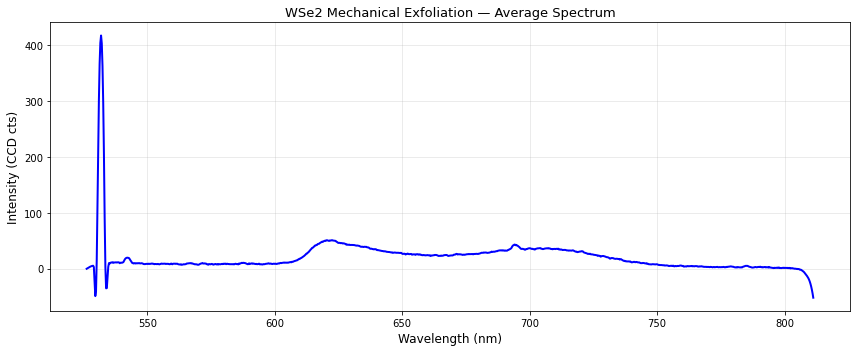

X축 범위: 526.2 ~ 811.3 nm
최대 강도 위치: 531.8 nm


In [17]:
# 기계적 박리 평균 스펙트럼 시각화
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

plt.figure(figsize=(12, 5))
plt.plot(x_exf, mean_exf_smooth, color='blue', linewidth=2)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('WSe2 Mechanical Exfoliation — Average Spectrum', fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'X축 범위: {x_exf.min():.1f} ~ {x_exf.max():.1f} nm')
print(f'최대 강도 위치: {x_exf[mean_exf_smooth.argmax()]:.1f} nm')

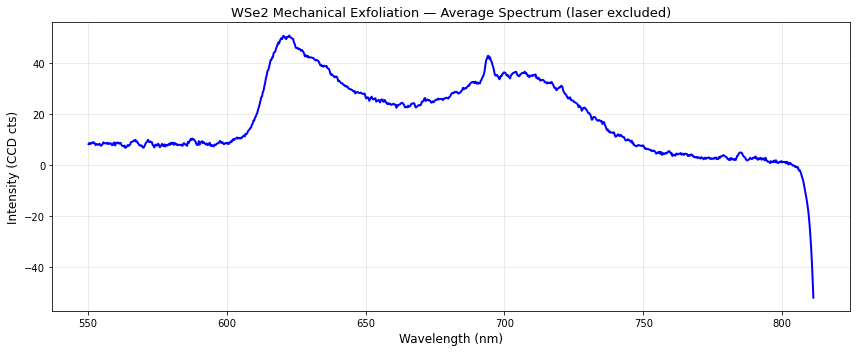

레이저 제외 후 피크:
  622.5 nm (1992 meV)
  694.2 nm (1786 meV)


In [19]:
# 기계적 박리 평균 스펙트럼 — 레이저 영역 제외 후 확인
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

# 레이저(532nm) 제외 — 550nm 이상만 표시
mask_laser = x_exf > 550

plt.figure(figsize=(12, 5))
plt.plot(x_exf[mask_laser], mean_exf_smooth[mask_laser],
         color='blue', linewidth=2)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('WSe2 Mechanical Exfoliation — Average Spectrum (laser excluded)',
          fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 레이저 제외 후 실제 피크 찾기
peaks_exf2, _ = find_peaks(
    mean_exf_smooth[mask_laser],
    height=mean_exf_smooth[mask_laser].max()*0.3,
    prominence=5
)
x_masked = x_exf[mask_laser]
print('레이저 제외 후 피크:')
for p in peaks_exf2:
    print(f'  {x_masked[p]:.1f} nm ({1239.8/x_masked[p]*1000:.0f} meV)')

C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from current font.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from current font.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 48149 (\N{HANGUL SYLLABLE BAG}) missing from current font.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from current font.
  plt.tight_layout()
C:\Users\kyb88\AppData\Local\Temp\ipykernel_9352\3927866071.py:32: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from current font.
  plt.tight_layout()
C:\U

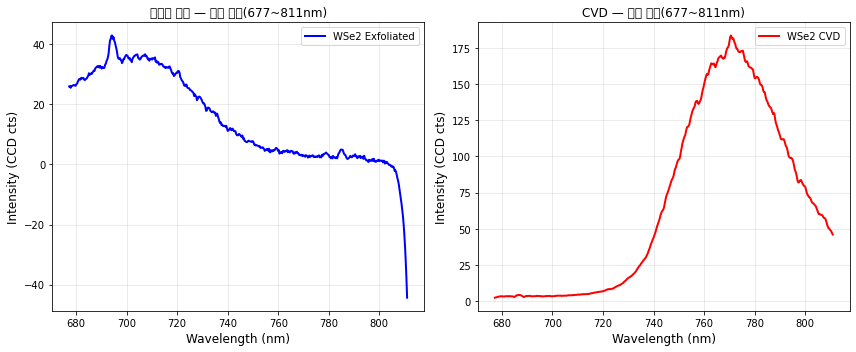

In [21]:
# 공통 범위(677~811nm)에서 기계적 박리 스펙트럼 확인
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

# 공통 범위만 선택
mask_common = (x_exf >= 677) & (x_exf <= 811)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x_exf[mask_common], mean_exf_smooth[mask_common],
         color='blue', linewidth=2, label='WSe2 Exfoliated')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('기계적 박리 — 공통 범위(677~811nm)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
baseline_cvd = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
mean_cvd = (spectra_cvd - baseline_cvd).mean(axis=0)
mean_cvd_smooth = savgol_filter(remove_cosmic_ray(mean_cvd), 15, 3)
mask_cvd = (x_cvd >= 677) & (x_cvd <= 811)
plt.plot(x_cvd[mask_cvd], mean_cvd_smooth[mask_cvd],
         color='red', linewidth=2, label='WSe2 CVD')
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('CVD — 공통 범위(677~811nm)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# CVD 데이터 다시 읽기 — 오른쪽 위 crop
print('WSe2 CVD 오른쪽 위 읽는 중...')
x_cvd, spectra_cvd = load_spectra(
    '1 Export File (Y-Axis).txt',
    '1 Export File (X-Axis).txt',
    row_start=5, row_end=35,
    col_start=30, col_end=60
)
print(f'CVD shape: {spectra_cvd.shape}')

# 평균 스펙트럼 피크 확인
baseline = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
mean_spec = (spectra_cvd - baseline).mean(axis=0)
mean_smooth = savgol_filter(remove_cosmic_ray(mean_spec), 15, 3)

peaks_cv, _ = find_peaks(mean_smooth,
                          height=mean_smooth.max()*0.3,
                          prominence=5)
print('\n피크 위치:')
for p in peaks_cv:
    print(f'  {x_cvd[p]:.1f} nm ({1239.8/x_cvd[p]*1000:.0f} meV)')

WSe2 CVD 오른쪽 위 읽는 중...
CVD shape: (900, 1024)

피크 위치:
  753.3 nm (1646 meV)


In [25]:
# CVD 처리
print('WSe2 CVD 처리 중...')
norm_cvd = process_spectra(spectra_cvd)
pos_cvd, int_cvd, fwhm_cvd = extract_peaks(norm_cvd, x_cvd)
print(f'CVD Peak position: {pos_cvd[pos_cvd>0].min():.1f} ~ {pos_cvd.max():.1f} nm')

# 기계적 박리 처리 (기존 데이터 재사용)
print('WSe2 기계적 박리 처리 중...')
norm_exf = process_spectra(spectra_exf)
pos_exf, int_exf, fwhm

WSe2 CVD 처리 중...
CVD Peak position: 678.3 ~ 946.5 nm
WSe2 기계적 박리 처리 중...


NameError: name 'fwhm' is not defined

In [27]:
def remove_cosmic_ray(s, threshold=5):
    med = np.median(s)
    std = np.std(s)
    mask = s > med + threshold * std
    sc = s.copy()
    for i in np.where(mask)[0]:
        if 0 < i < len(sc)-1:
            sc[i] = (sc[i-1] + sc[i+1]) / 2
    return sc

def process_spectra(spectra):
    baseline = np.percentile(spectra, 10, axis=1, keepdims=True)
    spectra_sub = spectra - baseline
    spectra_2d = spectra_sub.reshape(30, 30, 1024)
    row_means = spectra_2d.mean(axis=(1, 2), keepdims=True)
    global_mean = spectra_2d.mean()
    spectra_norm = spectra_2d * (global_mean / (row_means + 1e-10))
    return spectra_norm.reshape(900, 1024)

def extract_peaks(spectra_norm, x_axis):
    peak_positions = np.zeros((30, 30))
    peak_intensities = np.zeros((30, 30))
    fwhm_map = np.zeros((30, 30))
    for idx in range(900):
        row = idx // 30
        col = idx % 30
        spec = spectra_norm[idx]
        spec_clean = remove_cosmic_ray(spec)
        spec_smooth = savgol_filter(spec_clean, 15, 3)
        peaks, _ = find_peaks(spec_smooth,
                              height=spec_smooth.max()*0.3,
                              prominence=5)
        if len(peaks) > 0:
            main_peak = peaks[np.argmax(spec_smooth[peaks])]
            peak_positions[row, col] = x_axis[main_peak]
            peak_intensities[row, col] = spec_smooth[main_peak]
            half_max = spec_smooth[main_peak] / 2
            left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
            right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
            fwhm_map[row, col] = abs(x_axis[main_peak+right_idx] - x_axis[left_idx])
    return peak_positions, peak_intensities, fwhm_map

print('함수 정의 완료!')

# CVD 처리
print('WSe2 CVD 처리 중...')
norm_cvd = process_spectra(spectra_cvd)
pos_cvd, int_cvd, fwhm_cvd = extract_peaks(norm_cvd, x_cvd)
print(f'CVD Peak position: {pos_cvd[pos_cvd>0].min():.1f} ~ {pos_cvd.max():.1f} nm')

# 기계적 박리 처리
print('WSe2 기계적 박리 처리 중...')
norm_exf = process_spectra(spectra_exf)
pos_exf, int_exf, fwhm_exf = extract_peaks(norm_exf, x_exf)
print(f'Exf Peak position: {pos_exf[pos_exf>0].min():.1f} ~ {pos_exf.max():.1f} nm')
print('완료!')

함수 정의 완료!
WSe2 CVD 처리 중...
CVD Peak position: 678.3 ~ 946.5 nm
WSe2 기계적 박리 처리 중...
Exf Peak position: 531.8 ~ 784.4 nm
완료!


In [29]:
def extract_peaks_nm_cutoff(spectra_norm, x_axis, nm_min=550):
    """nm_min 이하 파장 제외하고 피크 추출"""
    peak_positions = np.zeros((30, 30))
    peak_intensities = np.zeros((30, 30))
    fwhm_map = np.zeros((30, 30))
    
    # 유효 파장 범위 마스크
    valid_range = x_axis > nm_min
    x_valid = x_axis[valid_range]
    
    for idx in range(900):
        row = idx // 30
        col = idx % 30
        spec = spectra_norm[idx][valid_range]
        spec_clean = remove_cosmic_ray(spec)
        spec_smooth = savgol_filter(spec_clean, 15, 3)
        peaks, _ = find_peaks(spec_smooth,
                              height=spec_smooth.max()*0.3,
                              prominence=5)
        if len(peaks) > 0:
            main_peak = peaks[np.argmax(spec_smooth[peaks])]
            peak_positions[row, col] = x_valid[main_peak]
            peak_intensities[row, col] = spec_smooth[main_peak]
            half_max = spec_smooth[main_peak] / 2
            left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
            right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
            fwhm_map[row, col] = abs(x_valid[main_peak+right_idx] - x_valid[left_idx])
    return peak_positions, peak_intensities, fwhm_map

# 기계적 박리 — 레이저 제외 후 다시 추출
print('기계적 박리 피크 재추출 중 (550nm 이하 제외)...')
pos_exf, int_exf, fwhm_exf = extract_peaks_nm_cutoff(norm_exf, x_exf, nm_min=550)

valid = pos_exf > 0
print(f'유효 픽셀: {valid.sum()}개')
print(f'Peak position: {pos_exf[valid].min():.1f} ~ {pos_exf[valid].ma

SyntaxError: EOL while scanning string literal (2397284460.py, line 36)

In [31]:
def remove_cosmic_ray(s, threshold=5):
    med = np.median(s)
    std = np.std(s)
    mask = s > med + threshold * std
    sc = s.copy()
    for i in np.where(mask)[0]:
        if 0 < i < len(sc)-1:
            sc[i] = (sc[i-1] + sc[i+1]) / 2
    return sc

def process_spectra(spectra):
    baseline = np.percentile(spectra, 10, axis=1, keepdims=True)
    spectra_sub = spectra - baseline
    spectra_2d = spectra_sub.reshape(30, 30, 1024)
    row_means = spectra_2d.mean(axis=(1, 2), keepdims=True)
    global_mean = spectra_2d.mean()
    spectra_norm = spectra_2d * (global_mean / (row_means + 1e-10))
    return spectra_norm.reshape(900, 1024)

def extract_peaks(spectra_norm, x_axis):
    peak_positions = np.zeros((30, 30))
    peak_intensities = np.zeros((30, 30))
    fwhm_map = np.zeros((30, 30))
    for idx in range(900):
        row = idx // 30
        col = idx % 30
        spec = spectra_norm[idx]
        spec_clean = remove_cosmic_ray(spec)
        spec_smooth = savgol_filter(spec_clean, 15, 3)
        peaks, _ = find_peaks(spec_smooth,
                              height=spec_smooth.max()*0.3,
                              prominence=5)
        if len(peaks) > 0:
            main_peak = peaks[np.argmax(spec_smooth[peaks])]
            peak_positions[row, col] = x_axis[main_peak]
            peak_intensities[row, col] = spec_smooth[main_peak]
            half_max = spec_smooth[main_peak] / 2
            left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
            right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
            fwhm_map[row, col] = abs(x_axis[main_peak+right_idx] - x_axis[left_idx])
    return peak_positions, peak_intensities, fwhm_map

print('함수 정의 완료!')

# CVD 처리
print('WSe2 CVD 처리 중...')
norm_cvd = process_spectra(spectra_cvd)
pos_cvd, int_cvd, fwhm_cvd = extract_peaks(norm_cvd, x_cvd)
print(f'CVD: {pos_cvd[pos_cvd>0].min():.1f} ~ {pos_cvd.max():.1f} nm')

# 기계적 박리 처리
print('WSe2 기계적 박리 처리 중...')
norm_exf = process_spectra(spectra_exf)
pos_exf, int_exf, fwhm_exf = extract_peaks(norm_exf, x_exf)
print(f'Exf: {pos_exf[pos_exf>0].min():.1f} ~ {pos_exf.max():.1f} nm')
print('완료!')

함수 정의 완료!
WSe2 CVD 처리 중...
CVD: 678.3 ~ 946.5 nm
WSe2 기계적 박리 처리 중...
Exf: 531.8 ~ 784.4 nm
완료!


In [33]:
def extract_peaks(spectra_norm, x_axis, laser_cutoff_nm=550):
    peak_positions = np.zeros((30, 30))
    peak_intensities = np.zeros((30, 30))
    fwhm_map = np.zeros((30, 30))
    
    # 레이저 파장 제외 마스크
    valid_range = x_axis > laser_cutoff_nm
    x_valid = x_axis[valid_range]
    
    for idx in range(900):
        row = idx // 30
        col = idx % 30
        spec = spectra_norm[idx][valid_range]
        spec_clean = remove_cosmic_ray(spec)
        spec_smooth = savgol_filter(spec_clean, 15, 3)
        peaks, _ = find_peaks(spec_smooth,
                              height=spec_smooth.max()*0.3,
                              prominence=5)
        if len(peaks) > 0:
            main_peak = peaks[np.argmax(spec_smooth[peaks])]
            peak_positions[row, col] = x_valid[main_peak]
            peak_intensities[row, col] = spec_smooth[main_peak]
            half_max = spec_smooth[main_peak] / 2
            left_idx = (np.abs(spec_smooth[:main_peak] - half_max)).argmin()
            right_idx = (np.abs(spec_smooth[main_peak:] - half_max)).argmin()
            fwhm_map[row, col] = abs(x_valid[main_peak+right_idx] - x_valid[left_idx])
    return peak_positions, peak_intensities, fwhm_map

print('함수 업데이트 완료!')

# CVD 재처리
print('WSe2 CVD 처리 중...')
norm_cvd = process_spectra(spectra_cvd)
pos_cvd, int_cvd, fwhm_cvd = extract_peaks(norm_cvd, x_cvd)
print(f'CVD: {pos_cvd[pos_cvd>0].min():.1f} ~ {pos_cvd.max():.1f} nm')

# 기계적 박리 재처리
print('WSe2 기계적 박리 처리 중...')
norm_exf = process_spectra(spectra_exf)
pos_exf, int_exf, fwhm_exf = extract_peaks(norm_exf, x_exf, laser_cutoff_nm=550)
print(f'Exf: {pos_exf[pos_exf>0].min():.1f} ~ {pos_exf.max():.1f} nm')
print('완료!')

함수 업데이트 완료!
WSe2 CVD 처리 중...
CVD: 678.3 ~ 946.5 nm
WSe2 기계적 박리 처리 중...
Exf: 555.0 ~ 793.5 nm
완료!


In [35]:
# 기계적 박리 평균 스펙트럼 직접 시각화
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

# 레이저 제외 (550nm 이상만)
mask = x_exf > 550
x_plot = x_exf[mask]
y_plot = mean_exf_smooth[mask]

plt.figure(figsize=(12, 5))
plt.plot(x_plot, y_plot, color='blue', linewidth=2)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('WSe2 Mechanical Exfoliation — Average Spectrum\n(laser excluded, >550nm)', fontsize=13)
plt.grid(True, alpha=0.3)

# 최대값 표시
max_idx = np.argmax(y_plot)
plt.axvline(x=x_plot[max_idx], color='red', linestyle='--', alpha=0.7)
plt.annotate(f'{x_plot[max_idx]:.1f} nm\n({1239.8/x_plot[max_idx]*1000:.0f} meV)',
             xy=(x_plot[max_idx], y_plot[max_idx]),
             xytext=(20, -30), textcoords='offset points',

SyntaxError: unexpected EOF while parsing (3876344095.py, line 23)

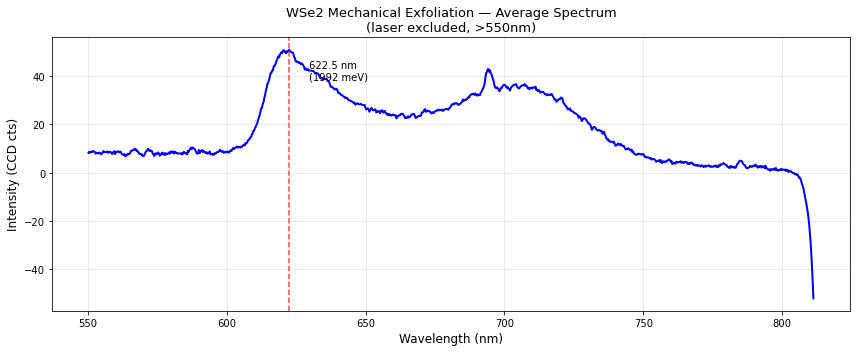

X축 범위: 550.2 ~ 811.3 nm
최대 강도 위치: 622.5 nm (1992 meV)


In [37]:
# 기계적 박리 평균 스펙트럼 직접 시각화
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

# 레이저 제외 (550nm 이상만)
mask = x_exf > 550
x_plot = x_exf[mask]
y_plot = mean_exf_smooth[mask]

plt.figure(figsize=(12, 5))
plt.plot(x_plot, y_plot, color='blue', linewidth=2)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Intensity (CCD cts)', fontsize=12)
plt.title('WSe2 Mechanical Exfoliation — Average Spectrum\n(laser excluded, >550nm)', fontsize=13)
plt.grid(True, alpha=0.3)

# 최대값 표시
max_idx = np.argmax(y_plot)
plt.axvline(x=x_plot[max_idx], color='red', linestyle='--', alpha=0.7)
plt.annotate(f'{x_plot[max_idx]:.1f} nm\n({1239.8/x_plot[max_idx]*1000:.0f} meV)',
             xy=(x_plot[max_idx], y_plot[max_idx]),
             xytext=(20, -30), textcoords='offset points', fontsize=10)
plt.tight_layout()
plt.show()
print(f'X축 범위: {x_plot.min():.1f} ~ {x_plot.max():.1f} nm')
print(f'최대 강도 위치: {x_plot[max_idx]:.1f} nm ({1239.8/x_plot[max_idx]*1000:.0f} meV)')

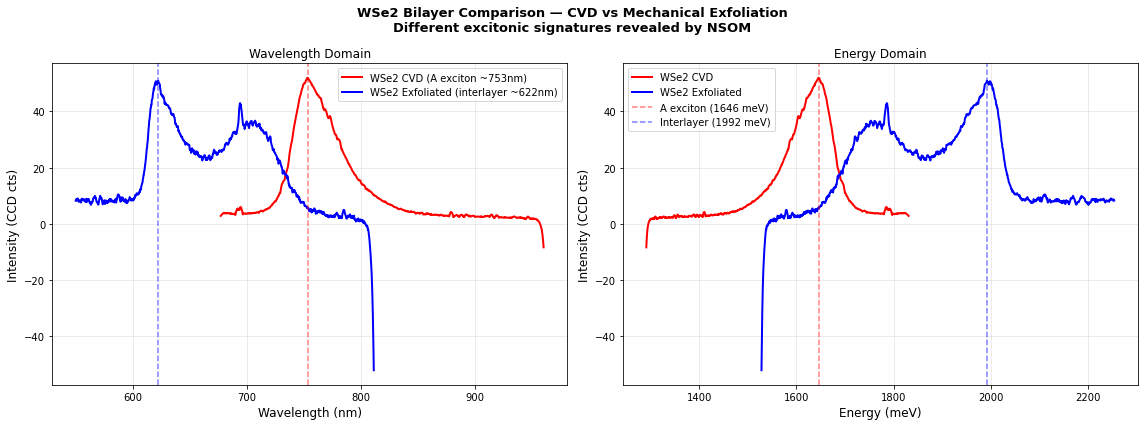

완료!


In [39]:
# 두 샘플 전체 스펙트럼 비교
baseline_cvd = np.percentile(spectra_cvd, 10, axis=1, keepdims=True)
baseline_exf = np.percentile(spectra_exf, 10, axis=1, keepdims=True)

mean_cvd = (spectra_cvd - baseline_cvd).mean(axis=0)
mean_exf = (spectra_exf - baseline_exf).mean(axis=0)

mean_cvd_smooth = savgol_filter(remove_cosmic_ray(mean_cvd), 15, 3)
mean_exf_smooth = savgol_filter(remove_cosmic_ray(mean_exf), 15, 3)

# 레이저 제외
mask_cvd = x_cvd > 550
mask_exf = x_exf > 550

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: nm 단위
axes[0].plot(x_cvd[mask_cvd], mean_cvd_smooth[mask_cvd],
             color='red', linewidth=2, label='WSe2 CVD (A exciton ~753nm)')
axes[0].plot(x_exf[mask_exf], mean_exf_smooth[mask_exf],
             color='blue', linewidth=2, label='WSe2 Exfoliated (interlayer ~622nm)')
axes[0].axvline(x=753.3, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=622.5, color='blue', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Wavelength (nm)', fontsize=12)
axes[0].set_ylabel('Intensity (CCD cts)', fontsize=12)
axes[0].set_title('Wavelength Domain', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# 오른쪽: meV 단위
x_cvd_meV = (1239.8 / x_cvd[mask_cvd]) * 1000
x_exf_meV = (1239.8 / x_exf[mask_exf]) * 1000

# meV는 역순이라 뒤집기
axes[1].plot(x_cvd_meV[::-1], mean_cvd_smooth[mask_cvd][::-1],
             color='red', linewidth=2, label='WSe2 CVD')
axes[1].plot(x_exf_meV[::-1], mean_exf_smooth[mask_exf][::-1],
             color='blue', linewidth=2, label='WSe2 Exfoliated')
axes[1].axvline(x=1646, color='red', linestyle='--', alpha=0.5,
                label='A exciton (1646 meV)')
axes[1].axvline(x=1992, color='blue', linestyle='--', alpha=0.5,
                label='Interlayer (1992 meV)')
axes[1].set_xlabel('Energy (meV)', fontsize=12)
axes[1].set_ylabel('Intensity (CCD cts)', fontsize=12)
axes[1].set_title('Energy Domain', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('WSe2 Bilayer Comparison — CVD vs Mechanical Exfoliation\n'
             'Different excitonic signatures revealed by NSOM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('WSe2_final_comparison.png', dpi=150)
plt.show()
print('완료!')